In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the RAW (before cleaning) files
df_2022_raw = pd.read_csv("before_cleaning_realestate_2022_q1.csv")
df_2023_raw = pd.read_csv("before_cleaning_realestate_2023_q1.csv")

In [ ]:
# shape of both datasets
print("2022 Q1 shape:", df_2022_raw.shape)
print("2023 Q1 shape:", df_2023_raw.shape)

2022 Q1 shape: (59846, 13)
2023 Q1 shape: (44091, 13)


In [ ]:
# look at the column names
print("2022 Q1 columns:")
print(df_2022_raw.columns.tolist())

print("\n2023 Q1 columns:")
print(df_2023_raw.columns.tolist())

2022 Q1 columns:
['رقم مرجعي', 'المنطقة', 'المدينة', 'الحي', 'المخطط', 'رقم القطعة', 'التاريخ', 'تصنيف العقار', 'نوع العقار', 'عدد العقارات', 'السعر بالريال السعودي', 'المساحة ', 'سعر المتر المربع']

2023 Q1 columns:
['رقم مرجعي', 'المنطقة', 'المدينة', 'الحي', 'المخطط', 'رقم القطعة', 'التاريخ', 'تصنيف العقار', 'نوع العقار', 'عدد العقارات', 'السعر بالريال السعودي', 'المساحة ', 'سعر المتر المربع']


In [ ]:
# Check data types
print("2022 Q1 info:")
df_2022_raw.info()

print("\n2023 Q1 info:")
df_2023_raw.info()

2022 Q1 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59846 entries, 0 to 59845
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   رقم مرجعي              59846 non-null  int64  
 1   المنطقة                59846 non-null  object 
 2   المدينة                59846 non-null  object 
 3   الحي                   59846 non-null  object 
 4   المخطط                 59846 non-null  object 
 5   رقم القطعة             59846 non-null  object 
 6   التاريخ                59846 non-null  object 
 7   تصنيف العقار           59846 non-null  object 
 8   نوع العقار             59846 non-null  object 
 9   عدد العقارات           59846 non-null  int64  
 10  السعر بالريال السعودي  59846 non-null  int64  
 11  المساحة                59846 non-null  float64
 12  سعر المتر المربع       59846 non-null  float64
dtypes: float64(2), int64(3), object(8)
memory usage: 5.9+ MB

2023 Q1 info:
<class 'pandas.core.

In [ ]:
# Check for missing values
print("Missing values in 2022 Q1:")
print(df_2022_raw.isnull().sum())

print("\nMissing values in 2023 Q1:")
print(df_2023_raw.isnull().sum())

Missing values in 2022 Q1:
رقم مرجعي                0
المنطقة                  0
المدينة                  0
الحي                     0
المخطط                   0
رقم القطعة               0
التاريخ                  0
تصنيف العقار             0
نوع العقار               0
عدد العقارات             0
السعر بالريال السعودي    0
المساحة                  0
سعر المتر المربع         0
dtype: int64

Missing values in 2023 Q1:
رقم مرجعي                0
المنطقة                  0
المدينة                  0
الحي                     0
المخطط                   0
رقم القطعة               0
التاريخ                  0
تصنيف العقار             0
نوع العقار               0
عدد العقارات             0
السعر بالريال السعودي    0
المساحة                  0
سعر المتر المربع         0
dtype: int64


In [ ]:
# Check for duplicate rows
print("Number of duplicate rows in 2022 Q1:", df_2022_raw.duplicated().sum())
print("Number of duplicate rows in 2023 Q1:", df_2023_raw.duplicated().sum())

Number of duplicate rows in 2022 Q1: 0
Number of duplicate rows in 2023 Q1: 0


In [ ]:
# Look at the price, space, and price per meter columns
price_col = 'السعر بالريال السعودي'
space_col = 'المساحة '
ppm_col = 'سعر المتر المربع'

print("2022 Q1 price/space/price_per_meter summary:")
print(df_2022_raw[[price_col, space_col, ppm_col]].describe())


print(df_2022_raw[[price_col]].describe()) # arabic make the column name revaiesd

2022 Q1 price/space/price_per_meter summary:
       السعر بالريال السعودي      المساحة   سعر المتر المربع
count           5.984600e+04  5.984600e+04      59846.000000
mean            8.687596e+05  4.921410e+03       1302.610391
std             5.347610e+06  6.591525e+04       2185.538330
min             1.000000e+04  2.830000e+00          0.010000
25%             1.400000e+05  4.037500e+02        207.429475
50%             3.800000e+05  6.000000e+02        646.106700
75%             8.000000e+05  7.800000e+02       1600.000000
max             7.456640e+08  4.348793e+06     139854.706400
       السعر بالريال السعودي
count           5.984600e+04
mean            8.687596e+05
std             5.347610e+06
min             1.000000e+04
25%             1.400000e+05
50%             3.800000e+05
75%             8.000000e+05
max             7.456640e+08


In [ ]:
# Check if there are any weird values like 0 or negative prices
print("How many rows have price <= 0?", (df_2022_raw[price_col] <= 0).sum())
print("How many rows have space <= 0?", (df_2022_raw[space_col] <= 0).sum())

How many rows have price <= 0? 0
How many rows have space <= 0? 0


In [ ]:
# Look at the unique categories
print("\nUnique property classifications:", df_2022_raw['تصنيف العقار'].unique(),"\n total of :" , df_2022_raw['تصنيف العقار'].nunique())
print("\nUnique property types:", df_2022_raw['نوع العقار'].unique(), "\n total of :" , df_2022_raw['نوع العقار'].nunique())
print("\nUnique property locations:", df_2022_raw['المنطقة'].unique(), "\n total of :" , df_2022_raw['المنطقة'].nunique())


Unique property classifications: ['سكني' 'تجاري' 'زراعي' 'صناعي'] 
 total of : 4

Unique property types: ['قطعة أرض' 'أرض زراعية' 'بيت' 'شقة' 'معرض/محل' 'فيلا' 'مرفق' 'إستراحة'
 'مركز تجاري' 'عمارة'] 
 total of : 10

Unique property locations: ['منطقة الرياض' 'منطقة مكة المكرمة' 'منطقة المدينة المنورة' 'منطقة القصيم'
 'المنطقة الشرقية' 'منطقة عسير' 'منطقة تبوك' 'منطقة حائل'
 'منطقة الحدود الشمالية' 'منطقة جازان' 'منطقة نجران' 'منطقة الباحة'
 'منطقة الجوف'] 
 total of : 13


In [ ]:
# Check the date column
print("Some date examples:", df_2022_raw['التاريخ'].unique()[:10])
print("Date column type:", df_2022_raw['التاريخ'].dtype)

Some date examples: ['2/1/2022' '2/2/2022' '2/3/2022' '2/4/2022' '2/5/2022' '2/6/2022'
 '2/7/2022' '2/8/2022' '2/9/2022' '2/10/2022']
Date column type: object


# the data here 2/10/2022  mean October ? but the data claim that is for Q1 ? so eithre we have a problem or it's read in the format of Month/Day/Yearso 2/10/2022 = Feb 10

## let's check

In [ ]:
# check the range so i can know where is the day and where is the month
print("2022 date range:", df_2022_raw['التاريخ'].min(), "to", df_2022_raw['التاريخ'].max())
print("2023 date range:", df_2023_raw['التاريخ'].min(), "to", df_2023_raw['التاريخ'].max())

# so prat one is Q1            part_1 / part_2 / part_3
#    part two is days            Q1      days     year

2022 date range: 2/1/2022 to 4/9/2022
2023 date range: 1/1/2023 to 3/9/2023


now i finished exploring the data let's start handling and transformation to be ready for visualisation


In [ ]:
 # Build a rename dictionary - to use it in the two dataset 2022 | 2023
column_rename = {
    'رقم مرجعي': 'ref_num',
    'المنطقة': 'area',
    'المدينة': 'city',
    'الحي': 'district',
    'المخطط': 'Mukatat',
    'رقم القطعة': 'piece_num',
    'التاريخ': 'date',
    'تصنيف العقار': 'property_classification',
    'نوع العقار': 'property_type',
    'عدد العقارات': 'number_of_properties',
    'السعر بالريال السعودي': 'price',
    'المساحة ': 'space',
    'سعر المتر المربع': 'Price_per_square_meter'
}

df_2022 = df_2022_raw.rename(columns=column_rename)
df_2023 = df_2023_raw.rename(columns=column_rename)

print("New columns:", df_2022.columns.tolist())

New columns: ['ref_num', 'area', 'city', 'district', 'Mukatat', 'piece_num', 'date', 'property_classification', 'property_type', 'number_of_properties', 'price', 'space', 'Price_per_square_meter']


In [ ]:
# Parse the date column properly now that we know the format is Month/Day/Year
df_2022['date'] = pd.to_datetime(df_2022['date'], format='%m/%d/%Y')
df_2023['date'] = pd.to_datetime(df_2023['date'], format='%m/%d/%Y')

In [ ]:
# check it worked - look at the date range
print("\n2022 date range:", df_2022['date'].min(), "to", df_2022['date'].max())
print("2023 date range:", df_2023['date'].min(), "to", df_2023['date'].max())



2022 date range: 2022-02-01 00:00:00 to 2022-04-14 00:00:00
2023 date range: 2023-01-01 00:00:00 to 2023-03-31 00:00:00


In [ ]:
# Extract year and quarter as separate columns (so we can compare with KAPSARC dataset later)
df_2022['year'] = df_2022['date'].dt.year
df_2022['quarter'] = df_2022['date'].dt.quarter
df_2023['year'] = df_2023['date'].dt.year
df_2023['quarter'] = df_2023['date'].dt.quarter

print("\n2022 quarter distribution:")
print(df_2022['quarter'].value_counts())

print("\n2023 quarter distribution:")
print(df_2023['quarter'].value_counts())


2022 quarter distribution:
quarter
1    51400
2     8446
Name: count, dtype: int64

2023 quarter distribution:
quarter
1    44091
Name: count, dtype: int64


# here we can see that dataset for 2022 also have Q2 = 8446 and it's likely 15%

## and dataset 2023 only Q1  

In [ ]:
# filter 2022 data down to Q1 only
print("Before filtering:", df_2022.shape)

df_2022 = df_2022[df_2022['quarter'] == 1].copy()

print("After filtering to true Q1 only:", df_2022.shape)

Before filtering: (59846, 15)
After filtering to true Q1 only: (51400, 15)


In [ ]:
# Check the exact region names in Kaggle before we build the translation

print("Unique regions in 2022:", sorted(df_2022['area'].unique()))
print("\nUnique regions in 2023:", sorted(df_2023['area'].unique()))

Unique regions in 2022: ['المنطقة الشرقية', 'منطقة الباحة', 'منطقة الجوف', 'منطقة الحدود الشمالية', 'منطقة الرياض', 'منطقة القصيم', 'منطقة المدينة المنورة', 'منطقة تبوك', 'منطقة جازان', 'منطقة حائل', 'منطقة عسير', 'منطقة مكة المكرمة', 'منطقة نجران']

Unique regions in 2023: ['المنطقة الشرقية', 'منطقة الباحة', 'منطقة الجوف', 'منطقة الحدود الشمالية', 'منطقة الرياض', 'منطقة القصيم', 'منطقة المدينة المنورة', 'منطقة تبوك', 'منطقة جازان', 'منطقة حائل', 'منطقة عسير', 'منطقة مكة المكرمة', 'منطقة نجران']


In [ ]:
# Build the Arab -> Eng mapping "the same English names KAPSARC uses"
region_map = {
    'منطقة الرياض': 'Riyadh',
    'منطقة مكة المكرمة': 'Makkah',
    'المنطقة الشرقية': 'Eastern Province',
    'منطقة القصيم': 'Al Qaseem',
    'منطقة المدينة المنورة': 'Madinah',
    'منطقة عسير': 'Aseer',
    'منطقة حائل': 'Hail',
    'منطقة تبوك': 'Tabouk',
    'منطقة الجوف': 'Al Jouf',
    'منطقة جازان': 'Jazan',
    'منطقة نجران': 'Najran',
    'منطقة الحدود الشمالية': 'Northern Borders',
    'منطقة الباحة': 'Al Baha'
}

df_2022['region_en'] = df_2022['area'].map(region_map)
df_2023['region_en'] = df_2023['area'].map(region_map)

In [ ]:
# check if any region failed to map
print("\nAny unmapped regions in 2022?", df_2022['region_en'].isnull().sum())
print("Any unmapped regions in 2023?", df_2023['region_en'].isnull().sum())


Any unmapped regions in 2022? 0
Any unmapped regions in 2023? 0


In [ ]:
# Build the Arab -> Eng mapping
classification_map = {
    'سكني': 'Residential',
    'تجاري': 'Commercial',
    'زراعي': 'Agricultural',
    'صناعي': 'Industrial'
}

df_2022['classification_en'] = df_2022['property_classification'].map(classification_map)
df_2023['classification_en'] = df_2023['property_classification'].map(classification_map)

In [ ]:
# check if any region failed to map
print("\nAny unmapped classifications in 2022?", df_2022['classification_en'].isnull().sum())
print("Any unmapped classifications in 2023?", df_2023['classification_en'].isnull().sum())


Any unmapped classifications in 2022? 0
Any unmapped classifications in 2023? 0


In [ ]:
# Build the Arab -> Eng mapping
property_type_map = {
    'قطعة أرض': 'Land Plot',
    'أرض زراعية': 'Agricultural Land',
    'بيت': 'House',
    'شقة': 'Apartment',
    'معرض/محل': 'Shop/Showroom',
    'فيلا': 'Villa',
    'مرفق': 'Facility',
    'إستراحة': 'Rest House',
    'مركز تجاري': 'Commercial Center',
    'عمارة': 'Building'
}

df_2022['property_type_en'] = df_2022['property_type'].map(property_type_map)
df_2023['property_type_en'] = df_2023['property_type'].map(property_type_map)

In [ ]:
# check if any region failed to map
print("Any unmapped property types in 2022?", df_2022['property_type_en'].isnull().sum())
print("Any unmapped property types in 2023?", df_2023['property_type_en'].isnull().sum())

Any unmapped property types in 2022? 0
Any unmapped property types in 2023? 0


In [ ]:
#check the actual counts for each property type
print("Property type counts - 2022 Q1:")
print(df_2022['property_type_en'].value_counts())

print("\nProperty type counts - 2023 Q1:")
print(df_2023['property_type_en'].value_counts())

Property type counts - 2022 Q1:
property_type_en
Land Plot            45071
Apartment             4086
Agricultural Land     1875
House                  218
Villa                   59
Shop/Showroom           49
Commercial Center       13
Building                12
Facility                 9
Rest House               8
Name: count, dtype: int64

Property type counts - 2023 Q1:
property_type_en
Land Plot            34897
Apartment             7157
Agricultural Land     1480
House                  316
Villa                   92
Shop/Showroom           82
Building                28
Facility                19
Commercial Center       11
Rest House               9
Name: count, dtype: int64


In [ ]:
rare_types = ['Facility', 'Rest House', 'Commercial Center', 'Building']

df_2022['property_type_grouped'] = df_2022['property_type_en'].apply(
    lambda x: 'Other' if x in rare_types else x
)
df_2023['property_type_grouped'] = df_2023['property_type_en'].apply(
    lambda x: 'Other' if x in rare_types else x
)

print("\n2022 grouped property type counts:")
print(df_2022['property_type_grouped'].value_counts())


2022 grouped property type counts:
property_type_grouped
Land Plot            45071
Apartment             4086
Agricultural Land     1875
House                  218
Villa                   59
Shop/Showroom           49
Other                   42
Name: count, dtype: int64


In [ ]:
# Combine both quarters into one dataframe
df_2022['source_quarter'] = '2022Q1'
df_2023['source_quarter'] = '2023Q1'

df_all = pd.concat([df_2022, df_2023], ignore_index=True)

In [ ]:
print("\nFinal columns:", df_all.columns.tolist())
print("\nFinal preview:")
print(df_all.head())

# Step 33: Save the cleaned files
df_2022.to_csv("clean_2022Q1.csv", index=False)
df_2023.to_csv("clean_2023Q1.csv", index=False)
df_all.to_csv("clean_combined.csv", index=False)
print("\nSaved: clean_2022Q1.csv, clean_2023Q1.csv, clean_combined.csv")


Final columns: ['ref_num', 'area', 'city', 'district', 'Mukatat', 'piece_num', 'date', 'property_classification', 'property_type', 'number_of_properties', 'price', 'space', 'Price_per_square_meter', 'year', 'quarter', 'region_en', 'classification_en', 'property_type_en', 'property_type_grouped', 'source_quarter']

Final preview:
    ref_num          area      city                                district  \
0  16074562  منطقة الرياض   الافلاج                             حي/الخالدية   
1  16077290  منطقة الرياض  البجاديه       حي/11 بالدخل المحدود غرب البجادية   
2  16077316  منطقة الرياض     الخرج  حي/60حى اليرموك مخطط 1009 الجزء الثانى   
3  16073025  منطقة الرياض     الخرج           حي/68 حى اليرموك مخطط 1009/ 2   
4  16069867  منطقة الرياض     الخرج                    حي/827 حى هجرة الصاع   

     Mukatat   piece_num       date property_classification property_type  \
0   مخطط/349    قطعة 255 2022-02-01                    سكني      قطعة أرض   
1  مخطط/أخرى    قطعة 448 2022-02-01    

In [ ]:
# Step 29: Translate property_type as well (for readable charts later)
property_type_map = {
    'قطعة أرض': 'Land Plot',
    'أرض زراعية': 'Agricultural Land',
    'بيت': 'House',
    'شقة': 'Apartment',
    'معرض/محل': 'Shop/Showroom',
    'فيلا': 'Villa',
    'مرفق': 'Facility',
    'إستراحة': 'Rest House',
    'مركز تجاري': 'Commercial Center',
    'عمارة': 'Building'
}

df_2022['property_type_en'] = df_2022['property_type'].map(property_type_map)
df_2023['property_type_en'] = df_2023['property_type'].map(property_type_map)

print("Any unmapped property types in 2022?", df_2022['property_type_en'].isnull().sum())
print("Any unmapped property types in 2023?", df_2023['property_type_en'].isnull().sum())

# Step 30: Group rare property types into "Other" for cleaner visualizations later
# (Facility, Rest House, Commercial Center, Building all had very low counts)
rare_types = ['Facility', 'Rest House', 'Commercial Center', 'Building']

df_2022['property_type_grouped'] = df_2022['property_type_en'].apply(
    lambda x: 'Other' if x in rare_types else x
)
df_2023['property_type_grouped'] = df_2023['property_type_en'].apply(
    lambda x: 'Other' if x in rare_types else x
)

print("\n2022 grouped property type counts:")
print(df_2022['property_type_grouped'].value_counts())

# Step 31: Combine both quarters into one dataframe (keeping source_quarter column to tell them apart)
df_2022['source_quarter'] = '2022Q1'
df_2023['source_quarter'] = '2023Q1'

df_all = pd.concat([df_2022, df_2023], ignore_index=True)

print("\nCombined shape:", df_all.shape)
print("\nRows per quarter:")
print(df_all['source_quarter'].value_counts())

# Step 32: Final check - look at the full cleaned dataframe
print("\nFinal columns:", df_all.columns.tolist())
print("\nFinal preview:")
print(df_all.head())

# Step 33: Save the cleaned files
df_2022.to_csv("clean_2022Q1.csv", index=False)
df_2023.to_csv("clean_2023Q1.csv", index=False)
df_all.to_csv("clean_combined.csv", index=False)

print("\nSaved: clean_2022Q1.csv, clean_2023Q1.csv, clean_combined.csv")

Any unmapped property types in 2022? 0
Any unmapped property types in 2023? 0

2022 grouped property type counts:
property_type_grouped
Land Plot            45071
Apartment             4086
Agricultural Land     1875
House                  218
Villa                   59
Shop/Showroom           49
Other                   42
Name: count, dtype: int64

Combined shape: (95491, 20)

Rows per quarter:
source_quarter
2022Q1    51400
2023Q1    44091
Name: count, dtype: int64

Final columns: ['ref_num', 'area', 'city', 'district', 'Mukatat', 'piece_num', 'date', 'property_classification', 'property_type', 'number_of_properties', 'price', 'space', 'Price_per_square_meter', 'year', 'quarter', 'region_en', 'classification_en', 'property_type_en', 'property_type_grouped', 'source_quarter']

Final preview:
    ref_num          area      city                                district  \
0  16074562  منطقة الرياض   الافلاج                             حي/الخالدية   
1  16077290  منطقة الرياض  البجاديه   

# now the data is in one datafream and ready to Exploratory Data

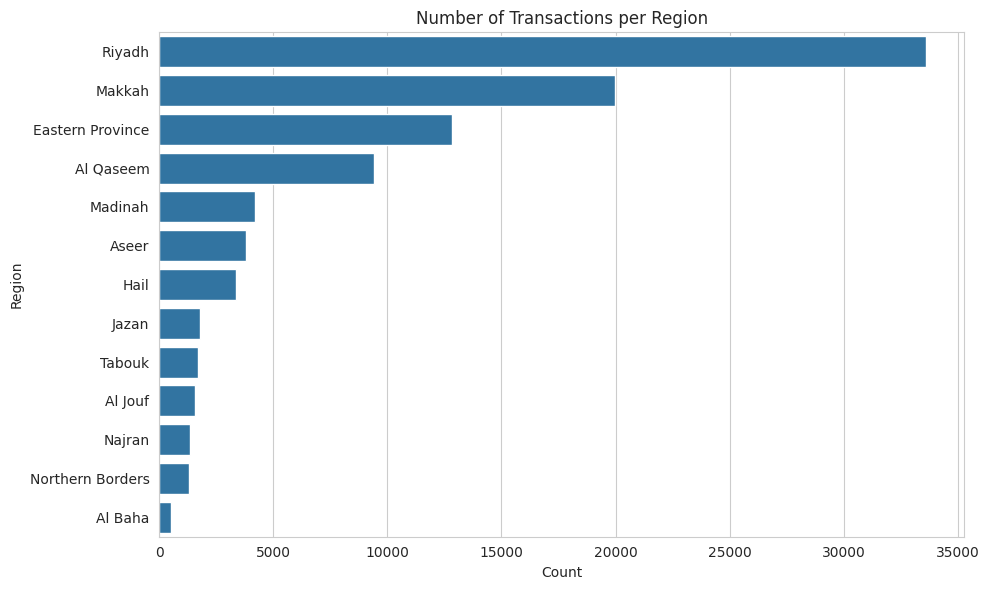

In [ ]:
#  How many listings per region?
plt.figure(figsize=(10,6))
sns.countplot(data=df_all, y='region_en', order=df_all['region_en'].value_counts().index)
plt.title("Number of Transactions per Region")
plt.xlabel("Count")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

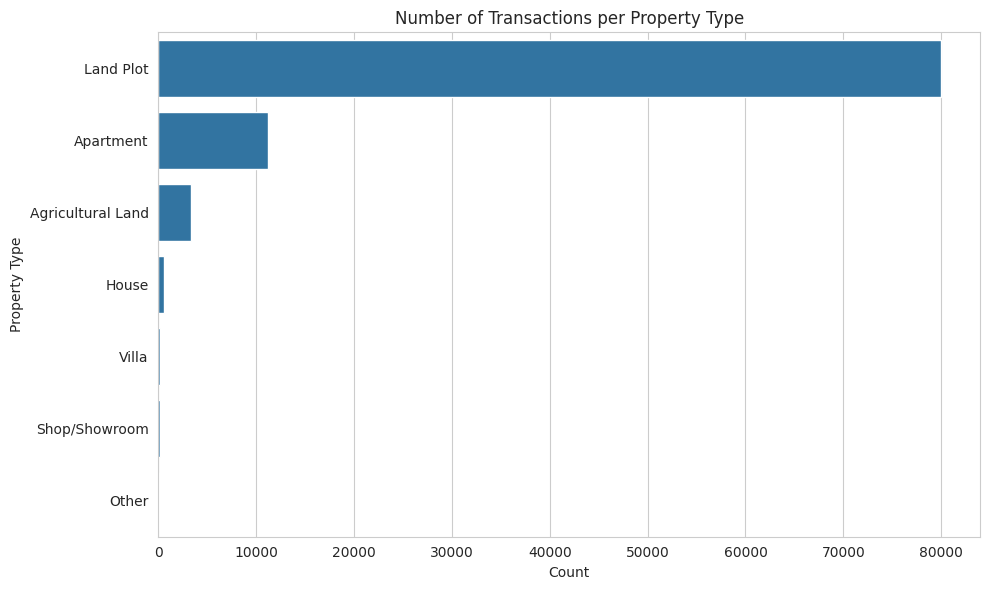

In [ ]:
#  How many listings per property type (grouped version)?
plt.figure(figsize=(10,6))
sns.countplot(data=df_all, y='property_type_grouped', order=df_all['property_type_grouped'].value_counts().index)
plt.title("Number of Transactions per Property Type")
plt.xlabel("Count")
plt.ylabel("Property Type")
plt.tight_layout()
plt.show()

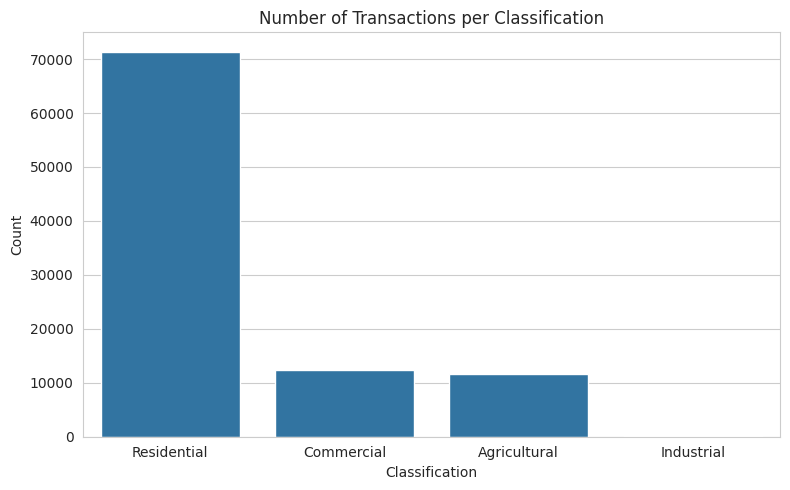

In [ ]:
# How many listings per classification?
plt.figure(figsize=(8,5))
sns.countplot(data=df_all, x='classification_en', order=df_all['classification_en'].value_counts().index)
plt.title("Number of Transactions per Classification")
plt.xlabel("Classification")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

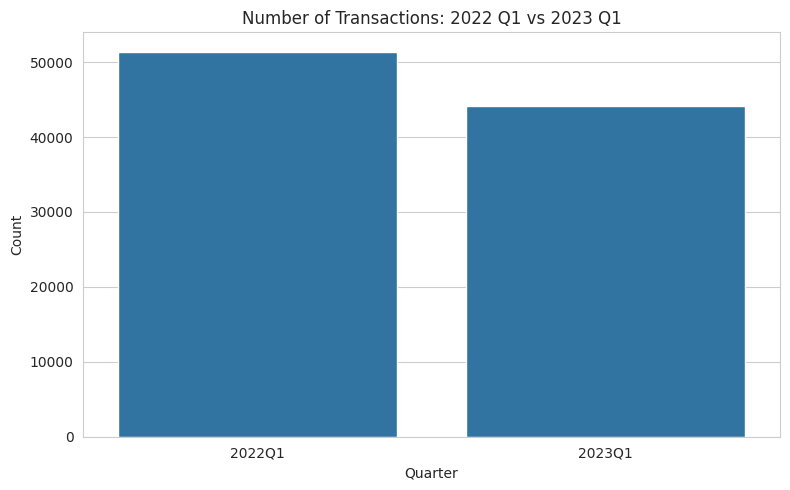

In [ ]:
# Compare 2022 Q1 vs 2023 Q1 volumes
plt.figure(figsize=(8,5))
sns.countplot(data=df_all, x='source_quarter')
plt.title("Number of Transactions: 2022 Q1 vs 2023 Q1")
plt.xlabel("Quarter")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

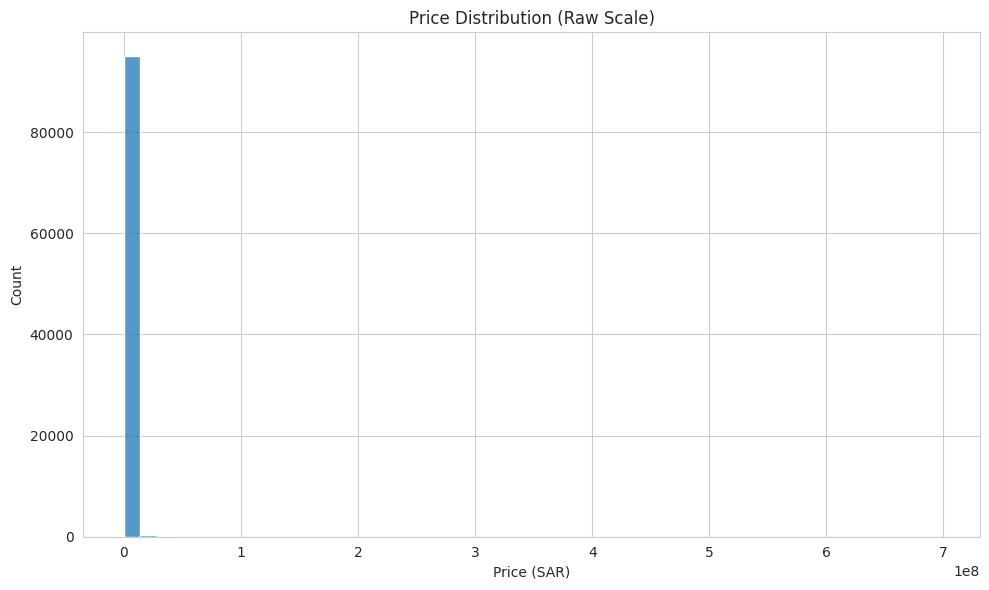

In [ ]:
# Price distribution - RAW (this will look bad because of the huge outliers we found earlier)
plt.figure(figsize=(10,6))
sns.histplot(data=df_all, x='price', bins=50)
plt.title("Price Distribution (Raw Scale)")
plt.xlabel("Price (SAR)")
plt.tight_layout()
plt.show()


## the data is extremely right-skewed

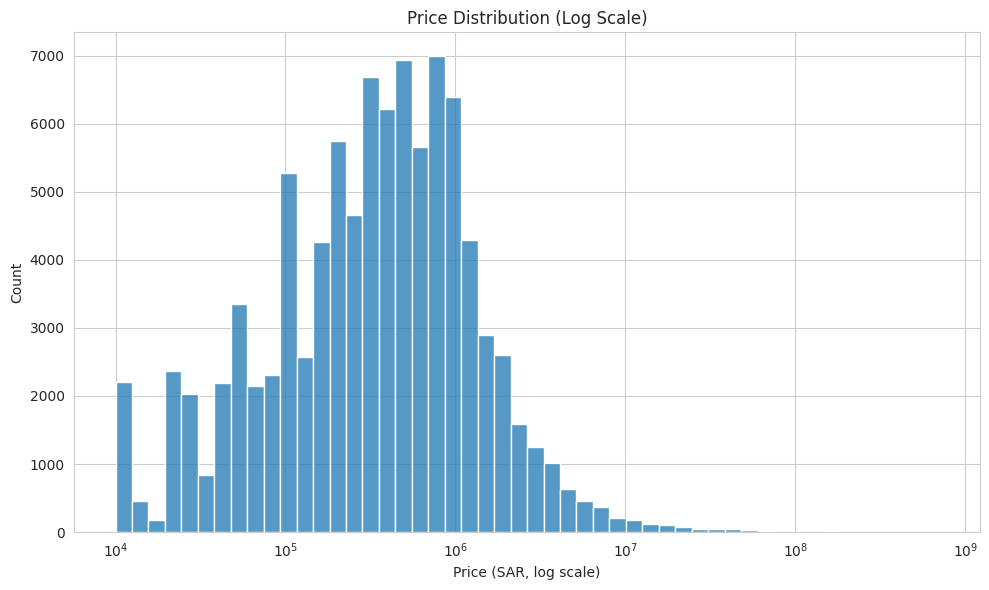

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_all, x='price', bins=50, log_scale=True)
plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price (SAR, log scale)")
plt.tight_layout()
plt.show()


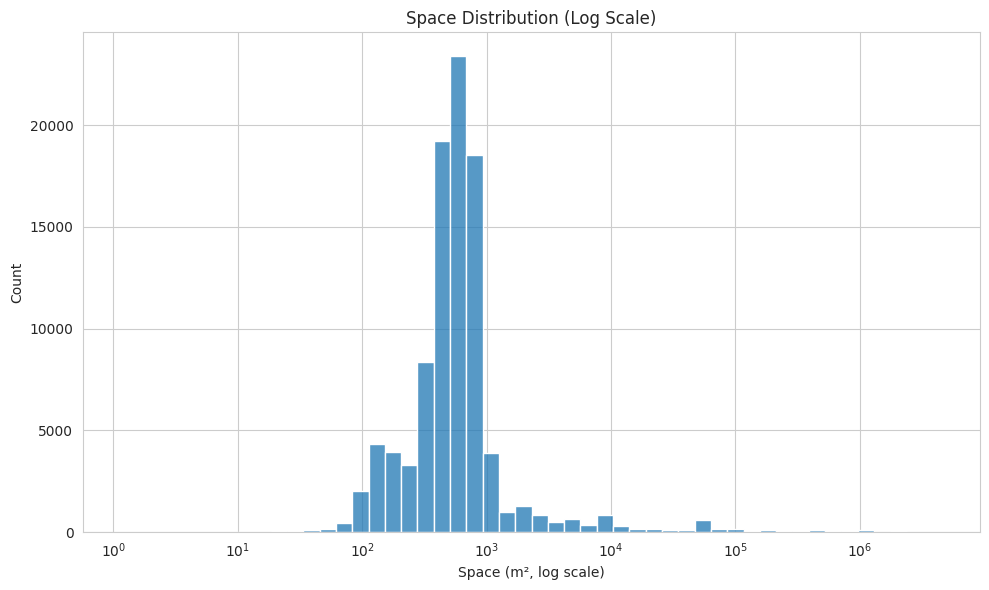

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_all, x='space', bins=50, log_scale=True)
plt.title("Space Distribution (Log Scale)")
plt.xlabel("Space (m², log scale)")
plt.tight_layout()
plt.show()

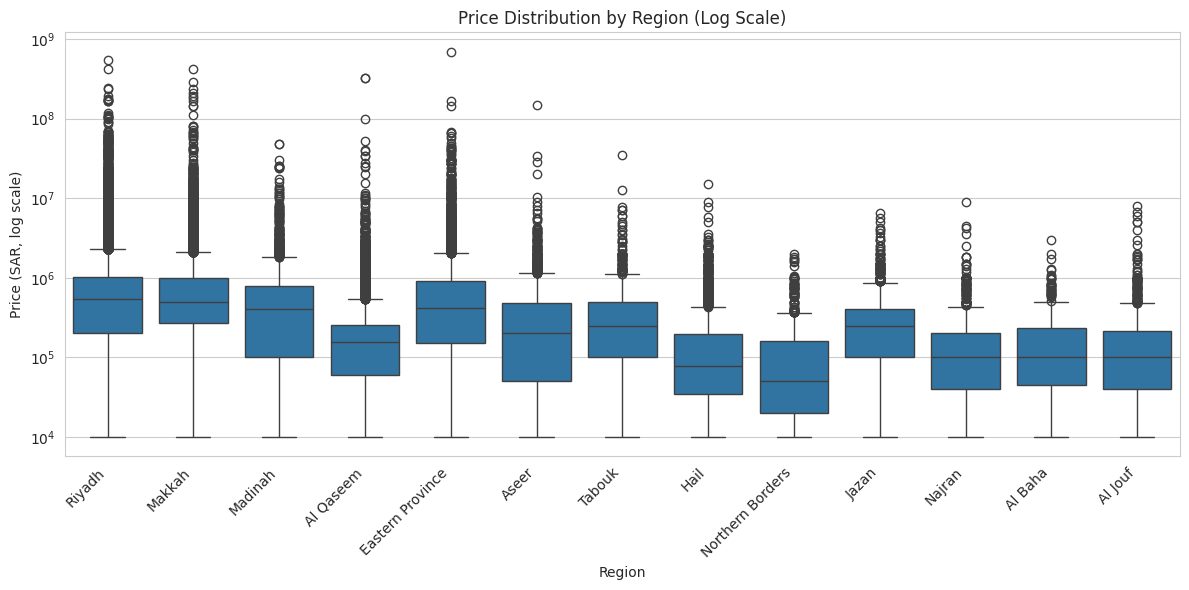

In [ ]:
# Boxplot of price by region
plt.figure(figsize=(12,6))
sns.boxplot(data=df_all, x='region_en', y='price')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title("Price Distribution by Region (Log Scale)")
plt.xlabel("Region")
plt.ylabel("Price (SAR, log scale)")
plt.tight_layout()
plt.show()


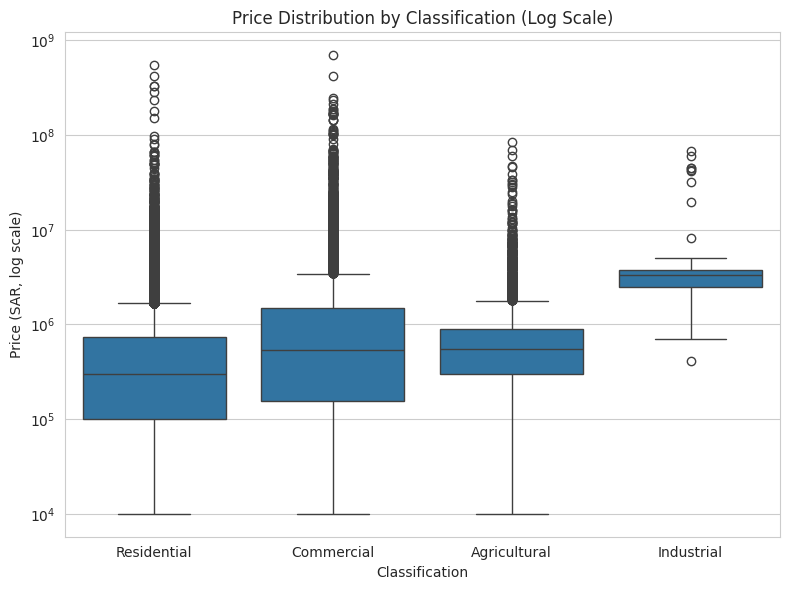

In [ ]:
# Boxplot of price by property classification
plt.figure(figsize=(8,6))
sns.boxplot(data=df_all, x='classification_en', y='price')
plt.yscale('log')
plt.title("Price Distribution by Classification (Log Scale)")
plt.xlabel("Classification")
plt.ylabel("Price (SAR, log scale)")
plt.tight_layout()
plt.show()

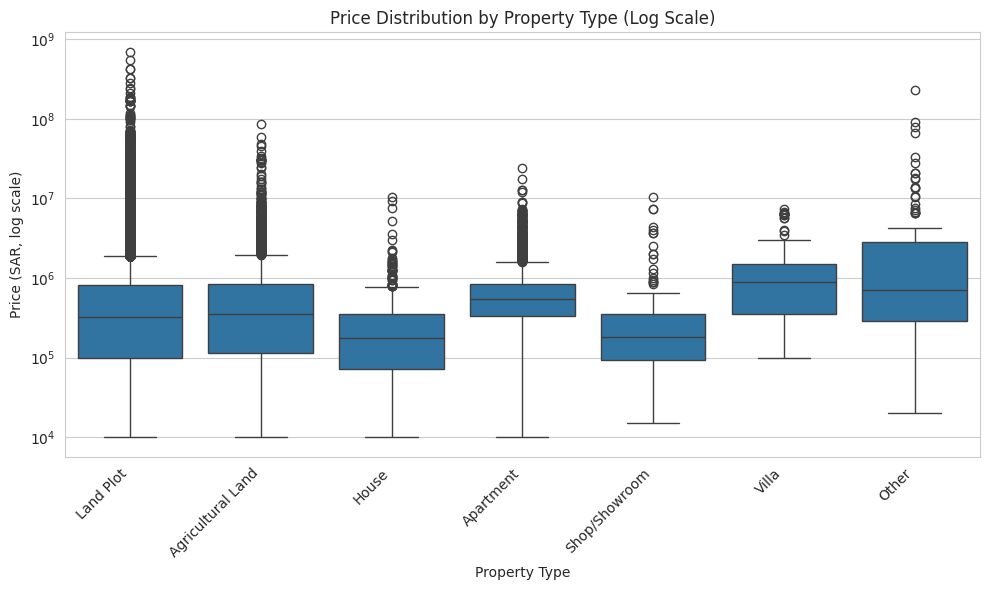

In [ ]:
# Boxplot of price by property type (grouped version)
plt.figure(figsize=(10,6))
sns.boxplot(data=df_all, x='property_type_grouped', y='price')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title("Price Distribution by Property Type (Log Scale)")
plt.xlabel("Property Type")
plt.ylabel("Price (SAR, log scale)")
plt.tight_layout()
plt.show()

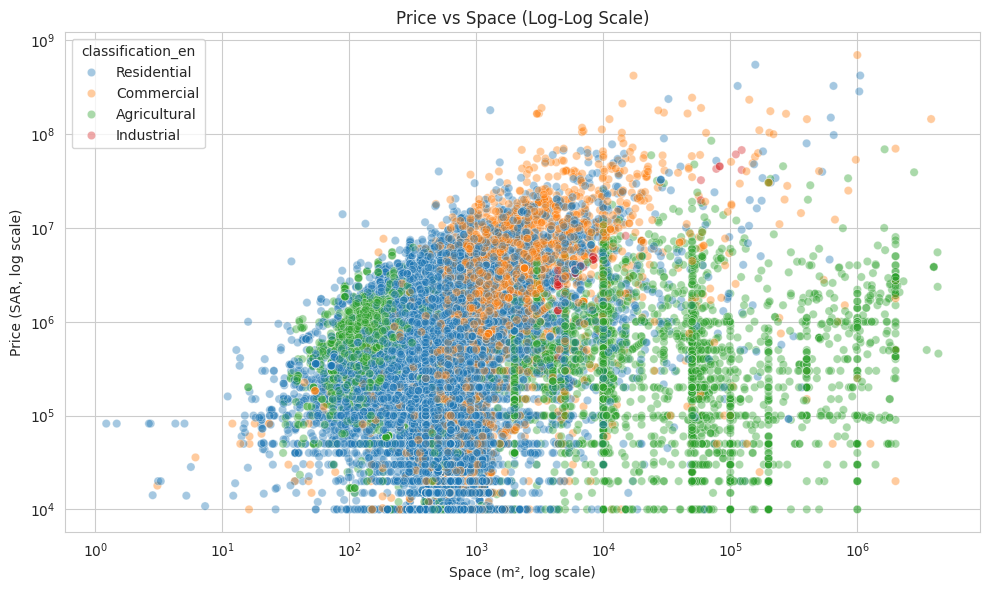

In [ ]:
# Scatter plot - price vs space
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_all, x='space', y='price', hue='classification_en', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title("Price vs Space (Log-Log Scale)")
plt.xlabel("Space (m², log scale)")
plt.ylabel("Price (SAR, log scale)")
plt.tight_layout()
plt.show()

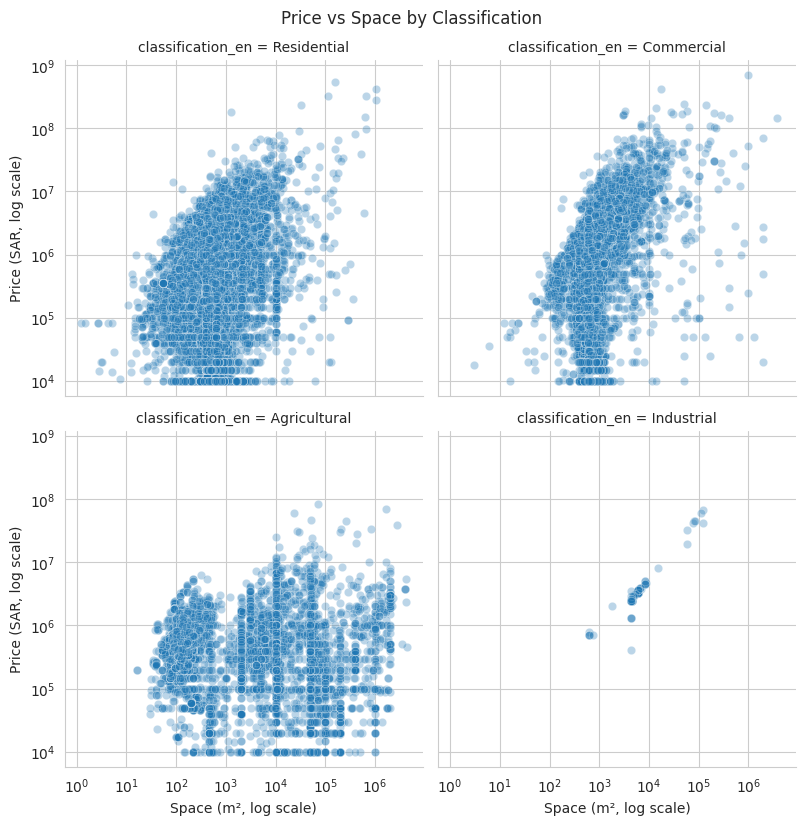

In [ ]:
g = sns.relplot(
    data=df_all, x='space', y='price', col='classification_en',
    col_wrap=2, alpha=0.3, height=4
)
g.set(xscale='log', yscale='log')
g.set_axis_labels("Space (m², log scale)", "Price (SAR, log scale)")
g.fig.suptitle("Price vs Space by Classification", y=1.02)
plt.show()

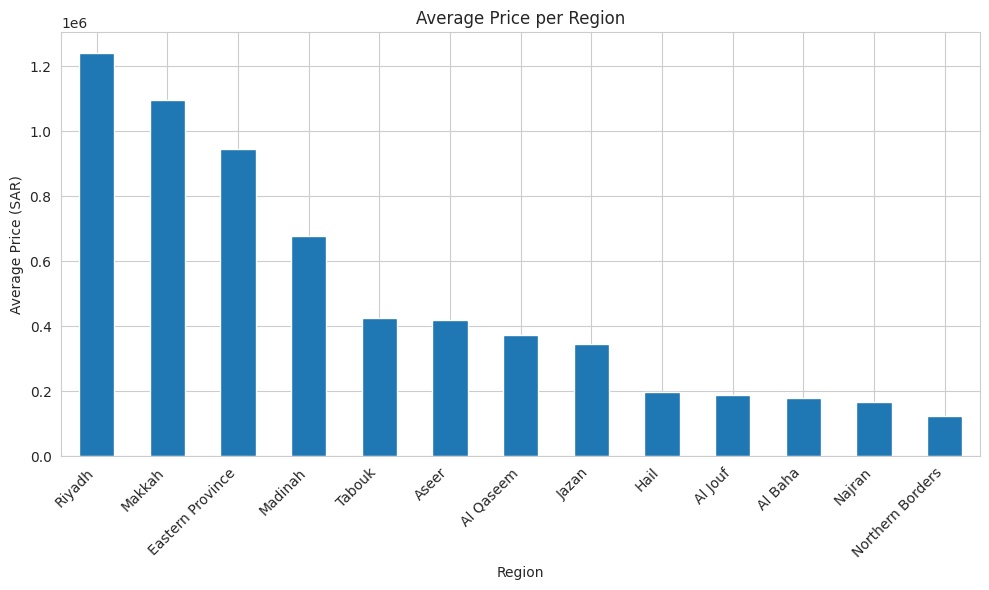

In [ ]:
# Bar plot - average price per region
avg_price_region = df_all.groupby('region_en')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_price_region.plot(kind='bar')
plt.title("Average Price per Region")
plt.xlabel("Region")
plt.ylabel("Average Price (SAR)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

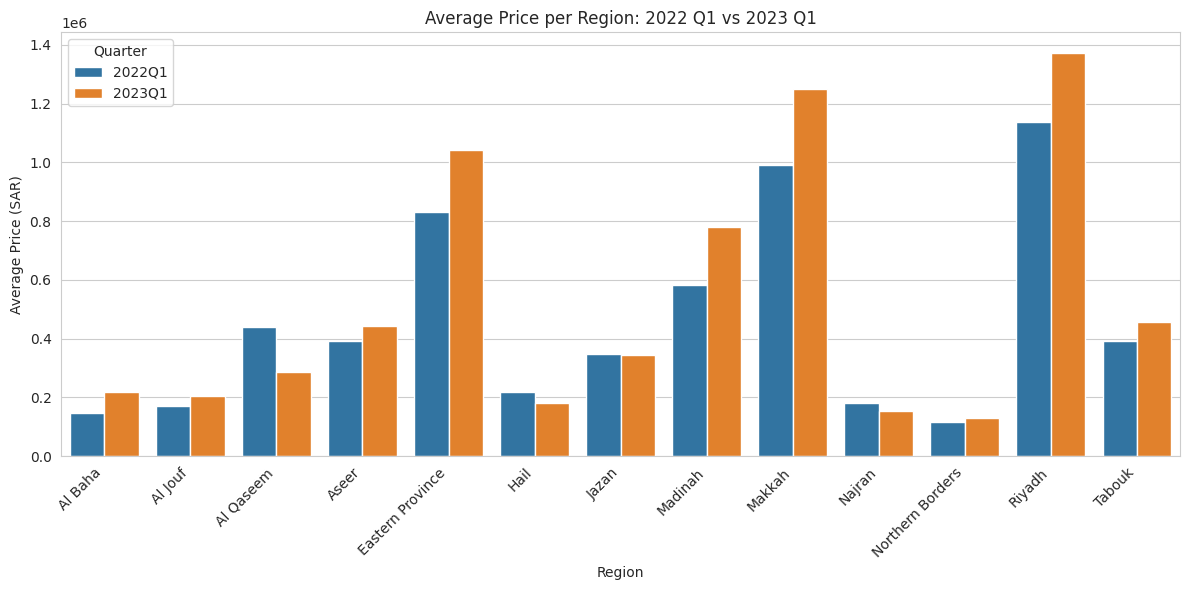

In [ ]:
# Bar plot - average price per region, split by quarter (2022 vs 2023)
avg_price_region_quarter = df_all.groupby(['region_en', 'source_quarter'])['price'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=avg_price_region_quarter, x='region_en', y='price', hue='source_quarter')
plt.title("Average Price per Region: 2022 Q1 vs 2023 Q1")
plt.xlabel("Region")
plt.ylabel("Average Price (SAR)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Quarter")
plt.tight_layout()
plt.show()

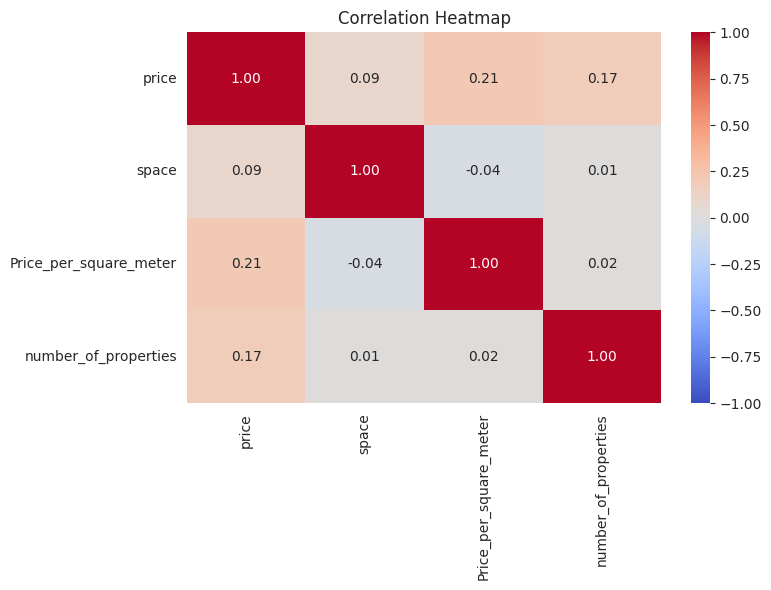

In [ ]:
# Correlation heatmap - only numeric columns
numeric_cols = ['price', 'space', 'Price_per_square_meter', 'number_of_properties']
corr_matrix = df_all[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Now i will work with KAPSARC dataset to compear and see if there any matchs in the two datasets

In [ ]:
import pandas as pd

kapsarc_df = pd.read_csv("real-estate-indices-by-regions-2023-100.csv", sep=';')

print(kapsarc_df.shape)
print(kapsarc_df.columns.tolist())
print("\n",kapsarc_df.head(10))

(938, 7)
['Periodicity', 'Year', 'Quarter', 'Measure', 'City', 'value', 'Date']

   Periodicity  Year Quarter Measure              City  value     Date
0   Quarterly  2021      Q1   Index             Aseer  88.47  2021-03
1   Quarterly  2021      Q1   Index            Najran  86.49  2021-03
2   Quarterly  2021      Q2   Index     Index Numbers  82.06  2021-06
3   Quarterly  2021      Q2   Index            Riyadh  74.86  2021-06
4   Quarterly  2021      Q2   Index            Makkah  86.70  2021-06
5   Quarterly  2021      Q2   Index  Eastern Province  92.74  2021-06
6   Quarterly  2021      Q3   Index              Hail  95.54  2021-09
7   Quarterly  2021      Q3   Index  Northern Borders  91.33  2021-09
8   Quarterly  2021      Q4   Index             Aseer  94.15  2021-12
9   Quarterly  2021      Q4   Index              Hail  97.27  2021-12


In [ ]:
# look at Measure and city
print("Unique Measure values:", kapsarc_df['Measure'].unique())
print()
print("Unique City values:", kapsarc_df['City'].unique())

Unique Measure values: ['Index' 'QoQ' 'YoY']

Unique City values: ['Aseer' 'Najran' 'Index Numbers' 'Riyadh' 'Makkah' 'Eastern Province'
 'Hail' 'Northern Borders' 'Al Qaseem' 'Tabouk' 'Jazan' 'Al Baha'
 'Al Jouf' 'Madinah']


In [ ]:
kapsarc_clean = kapsarc_df[kapsarc_df['City'] != 'Index Numbers'].copy()

print("Before:", kapsarc_df.shape)
print("After:", kapsarc_clean.shape)

Before: (938, 7)
After: (871, 7)


In [ ]:
# saparted by measure
kapsarc_index = kapsarc_clean[kapsarc_clean['Measure'] == 'Index'].copy()
kapsarc_yoy = kapsarc_clean[kapsarc_clean['Measure'] == 'YoY'].copy()
kapsarc_qoq = kapsarc_clean[kapsarc_clean['Measure'] == 'QoQ'].copy()

print("Index rows:", kapsarc_index.shape[0])
print("YoY rows:", kapsarc_yoy.shape[0])
print("QoQ rows:", kapsarc_qoq.shape[0])

Index rows: 338
YoY rows: 273
QoQ rows: 260


In [ ]:
print(kapsarc_yoy.head())
print(kapsarc_yoy.shape)

    Periodicity  Year Quarter Measure       City  value     Date
108   Quarterly  2022      Q1     YoY      Jazan   -1.9  2022-03
109   Quarterly  2022      Q2     YoY    Madinah   11.8  2022-06
110   Quarterly  2022      Q2     YoY  Al Qaseem   12.3  2022-06
111   Quarterly  2022      Q3     YoY     Riyadh   17.2  2022-09
112   Quarterly  2022      Q3     YoY    Madinah    5.0  2022-09
(273, 7)


In [ ]:
# Filter for 2023 and Q1
official_yoy_2023q1 = kapsarc_yoy[(kapsarc_yoy['Year'] == 2023) & (kapsarc_yoy['Quarter'] == 'Q1')].copy()

In [ ]:
# what i need only Region and % change
official_yoy_2023q1 = official_yoy_2023q1[['City', 'value']]
official_yoy_2023q1.columns = ['region', 'official_yoy_pct_change']
official_yoy_2023q1 = official_yoy_2023q1.sort_values('region')

print(official_yoy_2023q1.to_string(index=False))

          region  official_yoy_pct_change
         Al Baha                     -2.7
         Al Jouf                      9.6
       Al Qaseem                      6.3
           Aseer                      7.7
Eastern Province                      2.2
            Hail                      5.8
           Jazan                      6.6
         Madinah                      3.4
          Makkah                      8.8
          Najran                     14.8
Northern Borders                      0.8
          Riyadh                     11.6
          Tabouk                      6.1


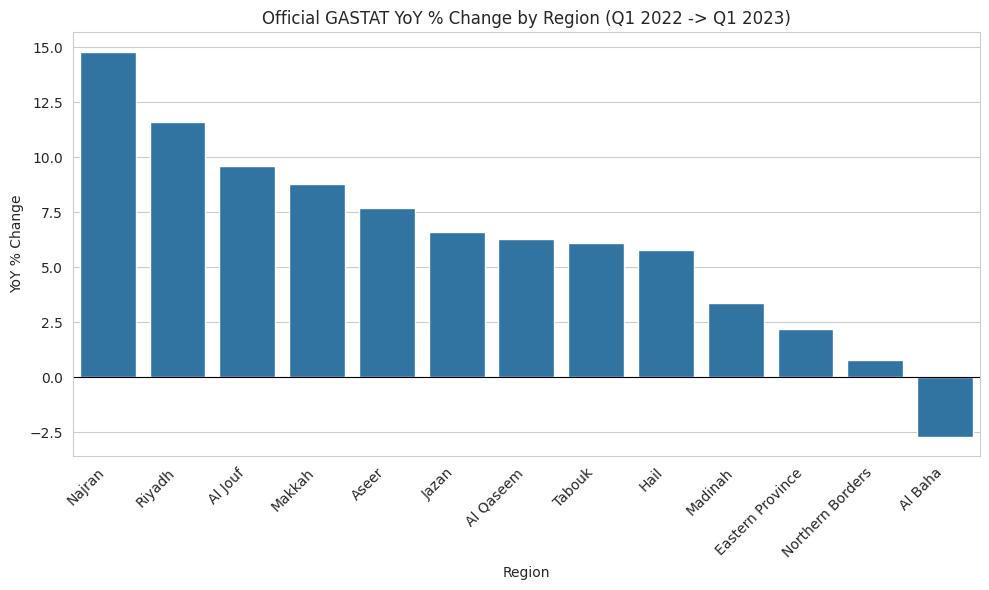

In [ ]:
plt.figure(figsize=(10,6))
sorted_yoy = official_yoy_2023q1.sort_values('official_yoy_pct_change', ascending=False)
sns.barplot(data=sorted_yoy, x='region', y='official_yoy_pct_change')
plt.title("Official GASTAT YoY % Change by Region (Q1 2022 -> Q1 2023)")
plt.xlabel("Region")
plt.ylabel("YoY % Change")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Average price per region, per quarter, from Kaggle
kaggle_avg = df_all.groupby(['region_en', 'source_quarter'])['price'].mean().reset_index()

# Reshape so each region has one row, with 2022Q1 and 2023Q1 as separate columns
kaggle_pivot = kaggle_avg.pivot(index='region_en', columns='source_quarter', values='price').reset_index()
kaggle_pivot.columns.name = None

# % change formula: (new - old) / old * 100 -- same formula GASTAT uses for YoY
kaggle_pivot['kaggle_pct_change'] = (kaggle_pivot['2023Q1'] - kaggle_pivot['2022Q1']) / kaggle_pivot['2022Q1'] * 100

print(kaggle_pivot[['region_en', 'kaggle_pct_change']].sort_values('region_en').to_string(index=False))

       region_en  kaggle_pct_change
         Al Baha          48.941010
         Al Jouf          19.907734
       Al Qaseem         -35.140174
           Aseer          13.116763
Eastern Province          25.064185
            Hail         -17.545447
           Jazan          -0.711908
         Madinah          33.849705
          Makkah          26.187437
          Najran         -15.057133
Northern Borders          12.328114
          Riyadh          20.752422
          Tabouk          16.281010


In [ ]:
# Merge Kaggle % change with GASTAT % change
comparison = kaggle_pivot.merge(
    official_yoy_2023q1,
    left_on='region_en',
    right_on='region',
    how='inner'
)

comparison = comparison[['region_en', 'kaggle_pct_change', 'official_yoy_pct_change']]
comparison.columns = ['region', 'kaggle_pct_change', 'official_pct_change']
comparison['difference'] = comparison['kaggle_pct_change'] - comparison['official_pct_change']

print(comparison.sort_values('official_pct_change', ascending=False).to_string(index=False))

          region  kaggle_pct_change  official_pct_change  difference
          Najran         -15.057133                 14.8  -29.857133
          Riyadh          20.752422                 11.6    9.152422
         Al Jouf          19.907734                  9.6   10.307734
          Makkah          26.187437                  8.8   17.387437
           Aseer          13.116763                  7.7    5.416763
           Jazan          -0.711908                  6.6   -7.311908
       Al Qaseem         -35.140174                  6.3  -41.440174
          Tabouk          16.281010                  6.1   10.181010
            Hail         -17.545447                  5.8  -23.345447
         Madinah          33.849705                  3.4   30.449705
Eastern Province          25.064185                  2.2   22.864185
Northern Borders          12.328114                  0.8   11.528114
         Al Baha          48.941010                 -2.7   51.641010


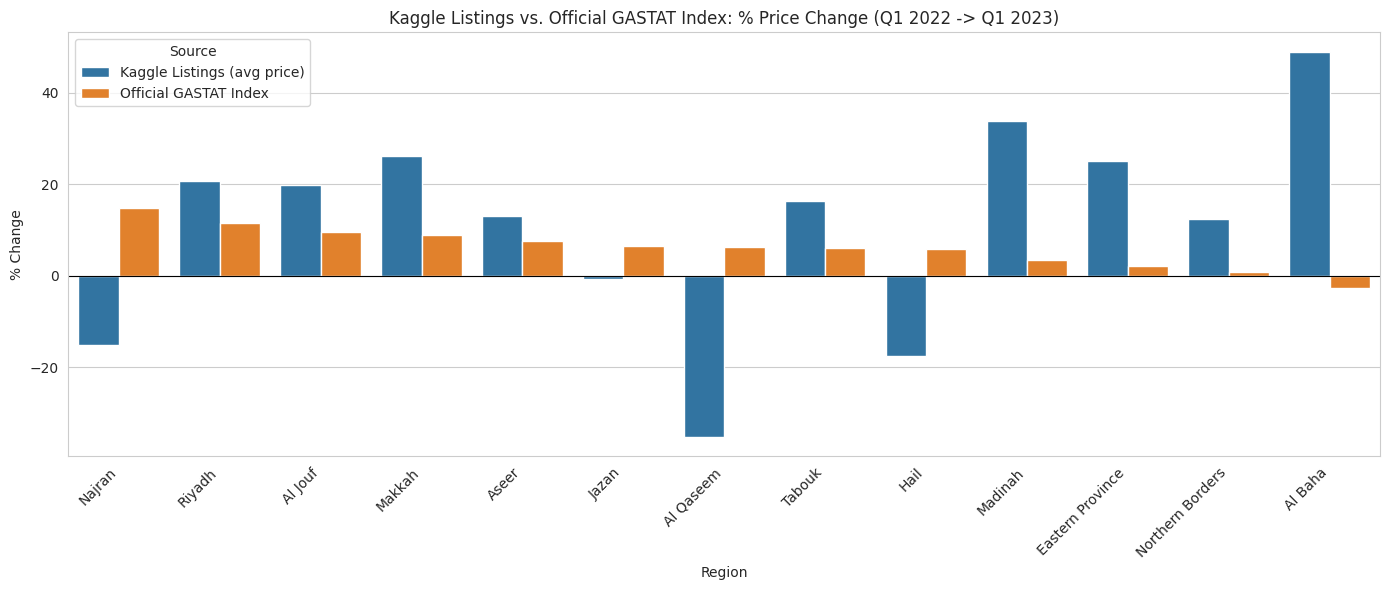

In [ ]:
# Reshape for a grouped bar chart (need "long" format for seaborn)
comparison_long = comparison.melt(
    id_vars='region',
    value_vars=['kaggle_pct_change', 'official_pct_change'],
    var_name='source',
    value_name='pct_change'
)

# Cleaner labels for the legend
comparison_long['source'] = comparison_long['source'].map({
    'kaggle_pct_change': 'Kaggle Listings (avg price)',
    'official_pct_change': 'Official GASTAT Index'
})

# Sort regions by official change, so the chart tells a clear story left to right
region_order = comparison.sort_values('official_pct_change', ascending=False)['region']

plt.figure(figsize=(14,6))
sns.barplot(data=comparison_long, x='region', y='pct_change', hue='source', order=region_order)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Kaggle Listings vs. Official GASTAT Index: % Price Change (Q1 2022 -> Q1 2023)")
plt.xlabel("Region")
plt.ylabel("% Change")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Source")
plt.tight_layout()
plt.show()


In [ ]:
 # Save the final comparison table too, for your report appendix
comparison.to_csv("final_comparison.csv", index=False)

# Insights Summary
### Patterns Discovered :
Land plots dominate the Kaggle data (~88% of transactions) in both quarters. Riyadh and Makkah have the highest average prices and transaction volumes, consistent with being the largest regions.
### Interesting Relationships :
Price and space are positively related, though loosely — especially for agricultural land, where price per m² varies a lot by location. The key relationship we tested was Kaggle's average price change vs. the official GASTAT index (Q1 2022 → Q1 2023). The official index rose steadily across almost all regions (+0.8% to +14.8%), while Kaggle's averages swung wildly (+48.9% to -35.1%), even disagreeing on direction in Najran, Al Qaseem, and Hail.
### Outliers:
Some land deals reached hundreds of millions of SAR and 4M+ m² in size — real, not errors. We used log scale to keep charts readable. These same outliers likely explain why Kaggle's averages diverged from the official index, especially in smaller regions with fewer transactions.

### Key Takeaways :

* Simple averages of raw listings ≠ a reliable price index — official, standardized methods matter.
* Small shifts in property mix per quarter can swing an average even if typical prices are stable.
* This is exactly why GASTAT's index methodology exists to avoid this exact problem.